In [2]:
# Ensure working directory to project code folder
import os

os.chdir("/ceph/behrens/peter_doohan/goalNav_opto-mFC/route_planning/code")
print("Current Working Directory: ", os.getcwd())

Current Working Directory:  /ceph/behrens/peter_doohan/goalNav_opto-mFC/route_planning/code


In [3]:
# configure matplotlib settings

from matplotlib import pyplot as plt

plt.rcParams.update(
    {
        "font.size": 10,
        "axes.titlesize": 10,
        "axes.labelsize": 10,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.titlesize": 10,
        "pdf.fonttype": 42,
    }
)

from importlib import reload
import numpy as np

In [4]:
from pathlib import Path

SAVE_FIG_PATH = Path("../results/figures/supp")

In [4]:
from GridMaze.analysis.anatomy import blobs as ab

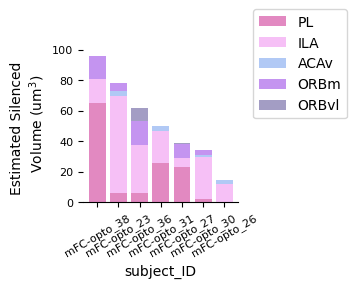

In [7]:
opto_anatomy_df = ab.get_opto_anatomy_df(condition="opto", verbose=False)
f, ax = plt.subplots(1, 1, figsize=(2, 2))
ab.plot_anatomy_summary(
    opto_anatomy_df,
    subject_order=[
        "mFC-opto_38",
        "mFC-opto_23",
        "mFC-opto_36",
        "mFC-opto_31",
        "mFC-opto_27",
        "mFC-opto_30",
        "mFC-opto_26",
    ],
    ax=ax,
)
f.savefig(SAVE_FIG_PATH / "anatomy_regions_summary.pdf")

In [3]:
from GridMaze.analysis.behaviour import learning as bl

learning_df = bl.get_learning_curve_df()
expert_df = bl.get_expert_performance_df()

Learning stats:
                  Mixed Linear Model Regression Results
Model:                  MixedLM      Dependent Variable:      total_trials
No. Observations:       75           Method:                  ML          
No. Groups:             15           Scale:                   198.2904    
Min. group size:        5            Log-Likelihood:          -319.4738   
Max. group size:        5            Converged:               Yes         
Mean group size:        5.0                                               
--------------------------------------------------------------------------
                               Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
--------------------------------------------------------------------------
Intercept                      28.525    7.579  3.764 0.000  13.670 43.380
condition[T.opto]              -8.511   11.095 -0.767 0.443 -30.257 13.235
day_on_maze                    16.875    1.574 10.719 0.000  13.789 19.961
condition[T.opto]:day_on_maz

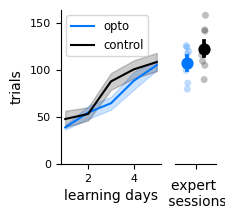

In [7]:
reload(bl)
fig, axes = plt.subplots(1, 2, figsize=(2, 2), width_ratios=[1, 0.4], sharey=True)
bl.plot_performance_summary(learning_df, expert_df, maze_order=2, print_stats=True, axes=axes)
fig.savefig(SAVE_FIG_PATH / "opto_trials_2.pdf")

In [5]:
from GridMaze.analysis.behaviour import performance_metrics as pm

performance_df = pm.get_performance_df()

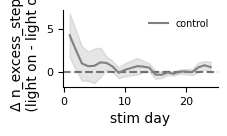

In [16]:
f, ax = plt.subplots(1, 1, figsize=(2, 1))
pm.plot_stim_effects_over_days(
    performance_df,
    y="n_excess_steps",
    groups=["control"],
    ax=ax,
)
f.savefig(SAVE_FIG_PATH / "control_excess_steps_over_days.pdf")

In [8]:
from GridMaze.analysis.core import get_sessions as gs
from GridMaze.analysis.behaviour import trajectory_plotting as tp

session = gs.get_maze_sessions(subject_IDs=["mFC-opto_23"], maze_names=["maze_2"], days_on_maze=[9])[0]

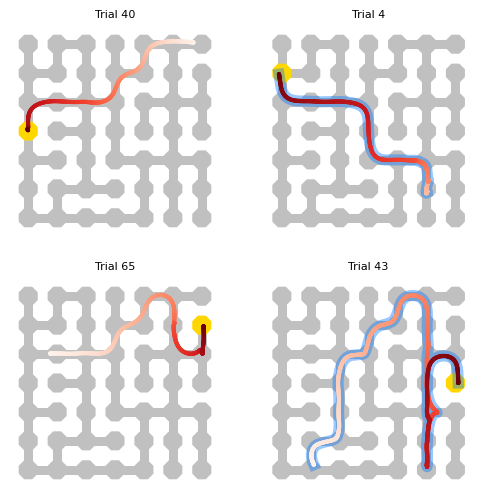

In [9]:
f, axes = plt.subplots(2, 2, figsize=(6, 6))
for ax, t in zip(axes.flatten(), [40, 4, 65, 43]):
    tp.plot_fancy_trial_trajectory(session, trial=t, ax=ax)
f.savefig(SAVE_FIG_PATH / "more_example_trials.pdf")

In [10]:
from GridMaze.analysis.behaviour import performance_metrics as pm
from GridMaze.analysis.behaviour import excess_steps as es

excess_steps_df = pm.get_performance_df()

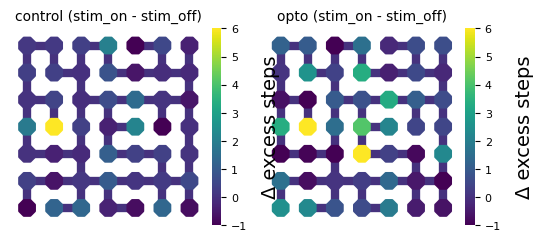

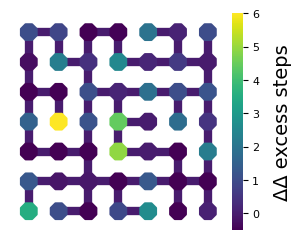

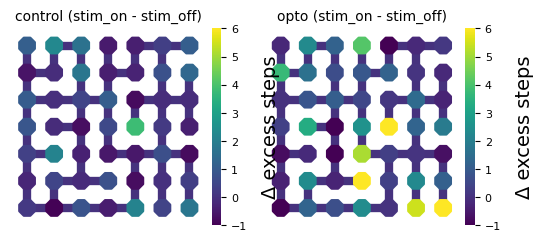

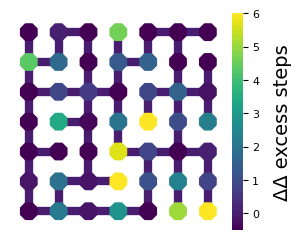

In [19]:
reload(es)
for maze in ["maze_1", "maze_2"]:
    f2, axes2 = plt.subplots(1, 2, figsize=(6, 3))
    f3, axes3 = plt.subplots(1, 1, figsize=(3, 3))
    for pa, v_range, axes in zip(
        ["delta", "delta_delta"],
        [(-1, 6), (-0.5, 6)],
        [axes2, axes3],
    ):
        es.plot_excess_steps_by_goal_heatmap_summary(
            excess_steps_df,
            outlier_thres=200,
            maze_name=maze,
            vmin=v_range[0],
            vmax=v_range[1],
            plot_as=pa,
            colormap="viridis",
            axes=axes,
        )
    f2.savefig(SAVE_FIG_PATH / f"goal_excess_steps_{maze}_{pa}.pdf")
    f3.savefig(SAVE_FIG_PATH / f"goal_excess_steps_{maze}_{pa}_control_opto.pdf")

T-tests on slope from delta xs steps linear fit:
  control vs opto: t(13)=-2.30, p=0.038
  control vs 0: t(7)=0.63, p=0.550
  opto vs 0: t(6)=2.70, p=0.035
T-tests on slope from delta xs steps linear fit:
  control vs opto: t(13)=2.00, p=0.067
  control vs 0: t(7)=-1.41, p=0.200
  opto vs 0: t(6)=-2.97, p=0.025


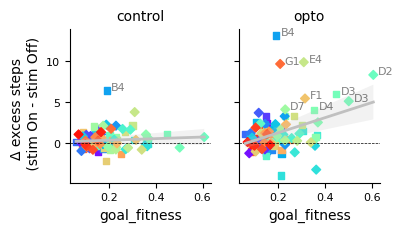

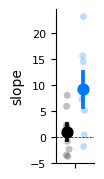

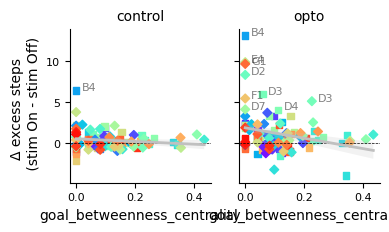

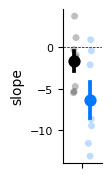

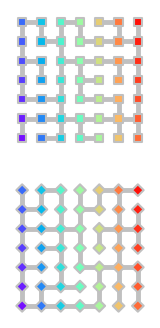

In [26]:
reload(es)
for var in ["goal_fitness", "goal_betweenness_centrality"]:
    f1, axes = plt.subplots(1, 2, figsize=(4, 2), sharey=True, sharex=True)
    f2, ax = plt.subplots(1, 1, figsize=(0.5, 2))
    es.plot_stratified_delta_excess_steps(
        excess_steps_df,
        stim_day_range=(6, np.inf),
        outlier_thres=200,
        var=var,
        axes=axes,
    )
    es.plot_delta_excess_steps_fit_slopes(
        excess_steps_df, stim_day_range=(6, np.inf), outlier_thres=200, var=var, print_stats=True, ax=ax
    )
    f1.savefig(SAVE_FIG_PATH / f"goal_excess_steps_stratified_delta_{var}.pdf")
    f2.savefig(SAVE_FIG_PATH / f"goal_excess_steps_stratified_delta_{var}_fit_slopes.pdf")

f, axes = plt.subplots(2, 1, figsize=(2, 4))
es.plot_special_maze_legend(axes=axes)
f.savefig(SAVE_FIG_PATH / "special_maze_legend.pdf")

In [10]:
from GridMaze.analysis.behaviour import distance_to_goal as dtg

ddtg_df = dtg.get_delta_distance_to_goal_df()

### subjects are still on task at start of navigation

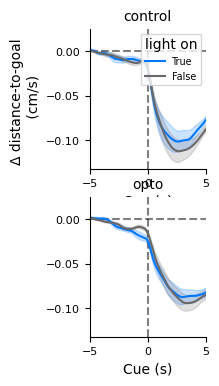

In [31]:
f, axes = plt.subplots(2, 1, figsize=(1.5, 4), sharey=True)
dtg.plot_delta_distance_to_goal_summary(ddtg_df, stim_day_range=(6, np.inf), axes=axes)
f.savefig(SAVE_FIG_PATH / "delta_distance_to_goal.pdf")

### Mixture of strategies modelling

In [13]:
from GridMaze.analysis.strategies import get_input_data as gid
from GridMaze.analysis.strategies import opto_effects as oe

navigation_strategies_df = gid.get_navigation_strategies_df(
    n_history=1,
    verbose=False,
)

Mixed ANOVA: vector
+-------------+------------+-------+-------+------------+----------+-----------+----------+-------+
| Source      |         SS |   DF1 |   DF2 |         MS |        F |     p-unc |      np2 |   eps |
|-------------+------------+-------+-------+------------+----------+-----------+----------+-------|
| condition   | 0.0190963  |     1 |    13 | 0.0190963  | 1.20267  | 0.292689  | 0.084679 |   nan |
| stim_trial  | 0.0189354  |     1 |    13 | 0.0189354  | 8.70644  | 0.0112574 | 0.401099 |     1 |
| Interaction | 0.00132106 |     1 |    13 | 0.00132106 | 0.607421 | 0.449717  | 0.044639 |   nan |
+-------------+------------+-------+-------+------------+----------+-----------+----------+-------+
Mixed ANOVA: structure
+-------------+------------+-------+-------+------------+-------------+----------+------------+-------+
| Source      |         SS |   DF1 |   DF2 |         MS |           F |    p-unc |        np2 |   eps |
|-------------+------------+-------+-------+-----

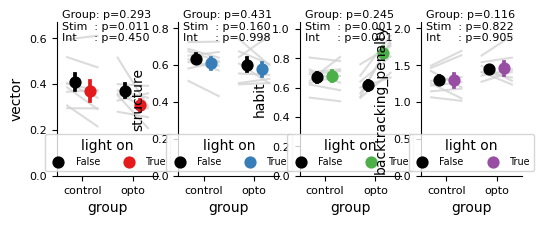

In [14]:
strategies = ["vector", "structure", "habit", "backtracking_penalty"]
results_df = oe.get_group_by_stim_strategy_weights(
    navigation_strategies_df[navigation_strategies_df.maze_name == "maze_1"],
    strategies=strategies,
    stim_day_range=(6, np.inf),
    max_trial_duration=None,
    stim_only=False,
)
fig, axes = plt.subplots(1, len(strategies), figsize=(1.5 * len(strategies), 2))
oe.plot_mixture_of_strategy_weights(results_df, axes=axes, cmap="Set1", print_stats=True)
fig.savefig(SAVE_FIG_PATH / "strategy_weights_maze_1.pdf")

Mixed ANOVA: vector
+-------------+-------------+-------+-------+-------------+----------+-----------+------------+-------+
| Source      |          SS |   DF1 |   DF2 |          MS |        F |     p-unc |        np2 |   eps |
|-------------+-------------+-------+-------+-------------+----------+-----------+------------+-------|
| condition   | 0.0725788   |     1 |    13 | 0.0725788   | 5.32475  | 0.0381214 | 0.290577   |   nan |
| stim_trial  | 0.00708533  |     1 |    13 | 0.00708533  | 1.56935  | 0.232367  | 0.107716   |     1 |
| Interaction | 0.000514729 |     1 |    13 | 0.000514729 | 0.114009 | 0.741015  | 0.00869368 |   nan |
+-------------+-------------+-------+-------+-------------+----------+-----------+------------+-------+
Mixed ANOVA: structure
+-------------+------------+-------+-------+------------+----------+-------------+----------+-------+
| Source      |         SS |   DF1 |   DF2 |         MS |        F |       p-unc |      np2 |   eps |
|-------------+----------

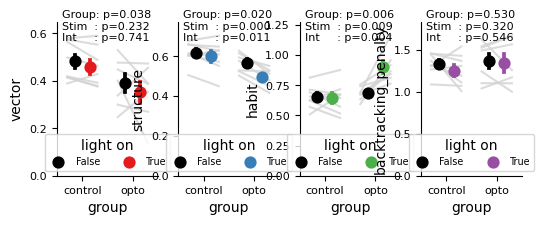

In [32]:
strategies = ["vector", "structure", "habit", "backtracking_penalty"]
results_df2 = oe.get_group_by_stim_strategy_weights(
    navigation_strategies_df[navigation_strategies_df.maze_name == "maze_2"],
    strategies=strategies,
    stim_day_range=(6, np.inf),
    max_trial_duration=None,
    stim_only=False,
)
fig, axes = plt.subplots(1, len(strategies), figsize=(1.5 * len(strategies), 2))
oe.plot_mixture_of_strategy_weights(results_df2, axes=axes, cmap="Set1", print_stats=True)
fig.savefig(SAVE_FIG_PATH / "strategy_weights_maze_2.pdf")

### off-target kinematic effects summary

In [27]:
from GridMaze.analysis.behaviour import movement as mv

stim_on_df = mv.get_aligned_speeds_df(aligned_to="stim_on", verbose=False)
stim_off_df = mv.get_aligned_speeds_df(aligned_to="stim_off", verbose=False)

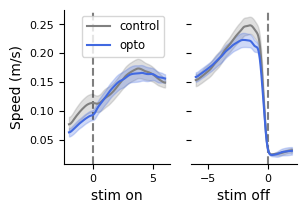

In [33]:
reload(mv)
f, axes = plt.subplots(1, 2, figsize=(3, 2), sharey=True)
mv.plot_stim_aligned_speeds_summary(stim_on_df, stim_off_df, axes=axes)
f.savefig(SAVE_FIG_PATH / "maze_stim_aligned_speeds_summary.pdf")

In [30]:
reload(mv)
stim_speeds_df = mv.get_stim_speeds_df()

Mixed ANOVA: average_speed
+-------------+-------------+-------+-------+-------------+---------+-----------+-----------+-------+
| Source      |          SS |   DF1 |   DF2 |          MS |       F |     p-unc |       np2 |   eps |
|-------------+-------------+-------+-------+-------------+---------+-----------+-----------+-------|
| condition   | 0.00114144  |     1 |    13 | 0.00114144  | 0.49026 | 0.496152  | 0.0363418 |   nan |
| stim_trial  | 0.0002014   |     1 |    13 | 0.0002014   | 3.53786 | 0.0825694 | 0.213925  |     1 |
| Interaction | 0.000431709 |     1 |    13 | 0.000431709 | 7.58355 | 0.0164174 | 0.368428  |   nan |
+-------------+-------------+-------+-------+-------------+---------+-----------+-----------+-------+


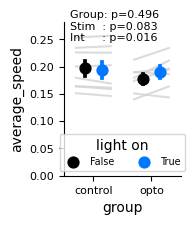

In [34]:
fig, ax = plt.subplots(1, 1, figsize=(1.5, 2))
mv.plot_stim_speeds_summary(stim_speeds_df, stim_day_range=(6, np.inf), ax=ax)
fig.savefig(SAVE_FIG_PATH / "maze_stim_speeds_summary.pdf")

### Other analyses not in paper

Mixed ANOVA: vector
+-------------+-------------+-------+-------+-------------+----------+-----------+-----------+-------+
| Source      |          SS |   DF1 |   DF2 |          MS |        F |     p-unc |       np2 |   eps |
|-------------+-------------+-------+-------+-------------+----------+-----------+-----------+-------|
| condition   | 0.0128769   |     1 |    13 | 0.0128769   | 0.815543 | 0.382915  | 0.0590308 |   nan |
| stim_trial  | 0.00772626  |     1 |    13 | 0.00772626  | 3.46009  | 0.0856374 | 0.210211  |     1 |
| Interaction | 0.000312229 |     1 |    13 | 0.000312229 | 0.139827 | 0.714481  | 0.0106415 |   nan |
+-------------+-------------+-------+-------+-------------+----------+-----------+-----------+-------+
Mixed ANOVA: structure_close
+-------------+-----------+-------+-------+-----------+---------+-----------+----------+-------+
| Source      |        SS |   DF1 |   DF2 |        MS |       F |     p-unc |      np2 |   eps |
|-------------+-----------+-------+-

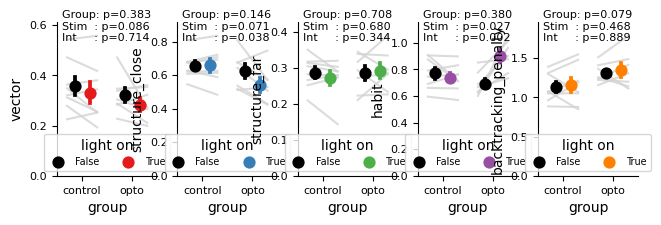

In [ ]:
strategies = ["vector", "structure_close", "structure_far", "habit", "backtracking_penalty"]
results_df = oe.get_group_by_stim_strategy_weights(
    navigation_strategies_df[navigation_strategies_df.maze_name == "maze_1"],
    strategies=strategies,
    stim_day_range=(4, np.inf),
    max_trial_duration=None,
    stim_only=False,
)
fig, axes = plt.subplots(1, len(strategies), figsize=(1.5 * len(strategies), 2))
oe.plot_mixture_of_strategy_weights(results_df, axes=axes, cmap="Set1", print_stats=True)

Mixed ANOVA: vector
+-------------+-------------+-------+-------+-------------+-----------+----------+------------+-------+
| Source      |          SS |   DF1 |   DF2 |          MS |         F |    p-unc |        np2 |   eps |
|-------------+-------------+-------+-------+-------------+-----------+----------+------------+-------|
| condition   | 0.0429831   |     1 |    13 | 0.0429831   | 2.81558   | 0.117216 | 0.178026   |   nan |
| stim_trial  | 0.00763163  |     1 |    13 | 0.00763163  | 1.31791   | 0.271654 | 0.0920464  |     1 |
| Interaction | 0.000234379 |     1 |    13 | 0.000234379 | 0.0404751 | 0.843668 | 0.00310381 |   nan |
+-------------+-------------+-------+-------+-------------+-----------+----------+------------+-------+
Mixed ANOVA: structure_close
+-------------+-----------+-------+-------+-----------+----------+-------------+----------+-------+
| Source      |        SS |   DF1 |   DF2 |        MS |        F |       p-unc |      np2 |   eps |
|-------------+--------

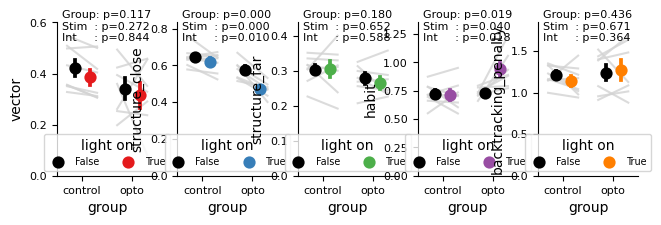

In [ ]:
strategies = ["vector", "structure_close", "structure_far", "habit", "backtracking_penalty"]
results_df = oe.get_group_by_stim_strategy_weights(
    navigation_strategies_df[navigation_strategies_df.maze_name == "maze_2"],
    strategies=strategies,
    stim_day_range=(4, np.inf),
    max_trial_duration=None,
    stim_only=False,
)
fig, axes = plt.subplots(1, len(strategies), figsize=(1.5 * len(strategies), 2))
oe.plot_mixture_of_strategy_weights(results_df, axes=axes, cmap="Set1", print_stats=True)

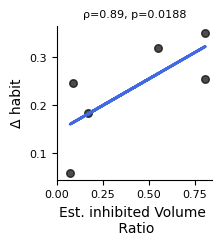

In [20]:
from GridMaze.analysis.anatomy import corr_behaviour as cb

reload(cb)
fig, ax = plt.subplots(1, 1, figsize=(2, 2))
cb.plot_anat_corr_behaviour(
    behavioural_metric="delta_habit",
    regions=["PL"],
    ratio=["PL", "ILA"],
    ax=ax,
)
fig.savefig(SAVE_FIG_PATH / "anat_corr_habit_weight.pdf")

In [21]:
from GridMaze.analysis.strategies import psychometrics as psy

psy_df = psy.get_psychometrics_df(
    navigation_strategies_df,
    stim_day_range=(6, np.inf),
    decision_points_only=True,
    x_bins=8,
)

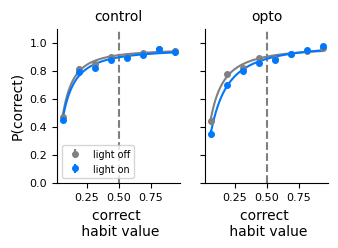

In [ ]:
reload(psy)
f, axes = plt.subplots(1, 2, figsize=(3.5, 2), sharey=True, sharex=True)

psy.plot_habit_psychometrics_summary(psy_df, fit="log_sigmoid", print_stats=False, axes=axes)

Mixed ANOVA: habit-value 0.062
+-------------+------------+-------+-------+------------+----------+-------------+----------+-------+
| Source      |         SS |   DF1 |   DF2 |         MS |        F |       p-unc |      np2 |   eps |
|-------------+------------+-------+-------+------------+----------+-------------+----------+-------|
| condition   | 0.0322263  |     1 |    13 | 0.0322263  |  4.51113 | 0.0534357   | 0.257615 |   nan |
| stim_trial  | 0.0240894  |     1 |    13 | 0.0240894  | 31.0403  | 9.05165e-05 | 0.704816 |     1 |
| Interaction | 0.00958707 |     1 |    13 | 0.00958707 | 12.3534  | 0.00380501  | 0.487248 |   nan |
+-------------+------------+-------+-------+------------+----------+-------------+----------+-------+
Mixed ANOVA: habit-value 0.1875
+-------------+------------+-------+-------+------------+----------+-------------+----------+-------+
| Source      |         SS |   DF1 |   DF2 |         MS |        F |       p-unc |      np2 |   eps |
|-------------+----

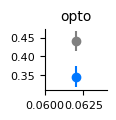

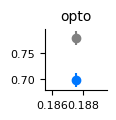

In [ ]:
reload(psy)
for inset_range in [(0.06, 0.064), (0.1855, 0.1895)]:
    f, ax = plt.subplots(1, 1, figsize=(0.8, 0.8))
    psy.plot_habit_psychometrics_inset(psy_df, group="opto", habit_value_range=inset_range, ax=ax)

In [24]:
fit_df = psy.get_curve_fit_df(psy_df, fit="log_sigmoid")

Mixed ANOVA: alpha
+-------------+------------+-------+-------+------------+-----------+------------+-----------+-------+
| Source      |         SS |   DF1 |   DF2 |         MS |         F |      p-unc |       np2 |   eps |
|-------------+------------+-------+-------+------------+-----------+------------+-----------+-------|
| condition   | 0.00161758 |     1 |    13 | 0.00161758 |  0.594122 | 0.454611   | 0.0437043 |   nan |
| stim_trial  | 0.00736132 |     1 |    13 | 0.00736132 | 16.7359   | 0.00127456 | 0.562818  |     1 |
| Interaction | 0.00382251 |     1 |    13 | 0.00382251 |  8.69044  | 0.0113162  | 0.400658  |   nan |
+-------------+------------+-------+-------+------------+-----------+------------+-----------+-------+


(0.05, 0.25)

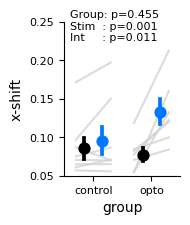

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(1.5, 2))
psy.plot_sigmoid_fit_params(fit_df, p=["alpha"], stim_color="#0077FF", axes=[ax])  # x-shift
ax.set_ylabel("x-shift")
ax.set_ylim(0.05, 0.25)

In [28]:
from GridMaze.analysis.errors import correction as corr
from GridMaze.analysis.errors import errors

error_df = errors.get_error_df()
results_df = corr.get_error_centered_df(
    error_df,
    n_jobs=-1,
)

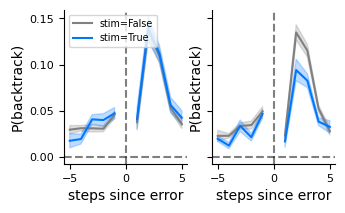

In [ ]:
reload(corr)
fig, axes = plt.subplots(1, 2, figsize=(3.5, 2), sharex=True, sharey=True)
corr.plot_prob_backtrack_after_error(results_df, axes=axes)